In [26]:
import pandas as pd
df=pd.read_csv("netflix-movies-and-tv-shows.zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
df.shape

(8807, 12)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [32]:
df['cast']=df['cast'].fillna('unknown')
df['cast'].head()

0                                              unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
Name: cast, dtype: object

In [34]:
df['cast'].str.split(',')

0                                               [unknown]
1       [Ama Qamata,  Khosi Ngema,  Gail Mabalane,  Th...
2       [Sami Bouajila,  Tracy Gotoas,  Samuel Jouy,  ...
3                                               [unknown]
4       [Mayur More,  Jitendra Kumar,  Ranjan Raj,  Al...
                              ...                        
8802    [Mark Ruffalo,  Jake Gyllenhaal,  Robert Downe...
8803                                            [unknown]
8804    [Jesse Eisenberg,  Woody Harrelson,  Emma Ston...
8805    [Tim Allen,  Courteney Cox,  Chevy Chase,  Kat...
8806    [Vicky Kaushal,  Sarah-Jane Dias,  Raaghav Cha...
Name: cast, Length: 8807, dtype: object

In [36]:
df.dropna(subset=['country']).head(3)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [38]:
df['date_added']=df['date_added'].astype(str).str.strip()
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [16]:
df['date_added'].isnull().sum()

10

In [40]:
df['date_added'].min()

Timestamp('2008-01-01 00:00:00')

In [24]:
df['date_added'].max()

Timestamp('2021-09-25 00:00:00')

In [178]:
recent=df[(df['date_added'].dt.year >= 2017)&(df['date_added'].dt.year<=2021)]
recent.head(3)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[United States]
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",[South Africa]
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,[unknown]


In [188]:
recent.shape[0]

8230

In [190]:
recent['date_added'].dt.year.value_counts()

date_added
2019    2016
2020    1879
2018    1649
2021    1498
2017    1188
Name: count, dtype: int64

In [48]:
movies=df[df['type']=='Movie'].copy()
tv_shows=df[df['type']=='TV Show'].copy()
movies['duration']=movies['duration'].astype(str)
tv_shows['duration']=tv_shows['duration'].astype(str)
movies['duration_min']=movies['duration'].str.split().str[0].astype(float)
tv_shows['seasons']=tv_shows['duration'].str.split().str[0].astype(int)
print(movies[['title','duration','duration_min',]].head())
print(tv_shows[['title','duration','seasons']].head())

                               title duration  duration_min
0               Dick Johnson Is Dead   90 min          90.0
6   My Little Pony: A New Generation   91 min          91.0
7                            Sankofa  125 min         125.0
9                       The Starling  104 min         104.0
12                      Je Suis Karl  127 min         127.0
                   title   duration  seasons
1          Blood & Water  2 Seasons        2
2              Ganglands   1 Season        1
3  Jailbirds New Orleans   1 Season        1
4           Kota Factory  2 Seasons        2
5          Midnight Mass   1 Season        1


In [200]:
#movies['duration_min'].isnull().sum()
movies['duration_min'].mean().round(2)

99.58

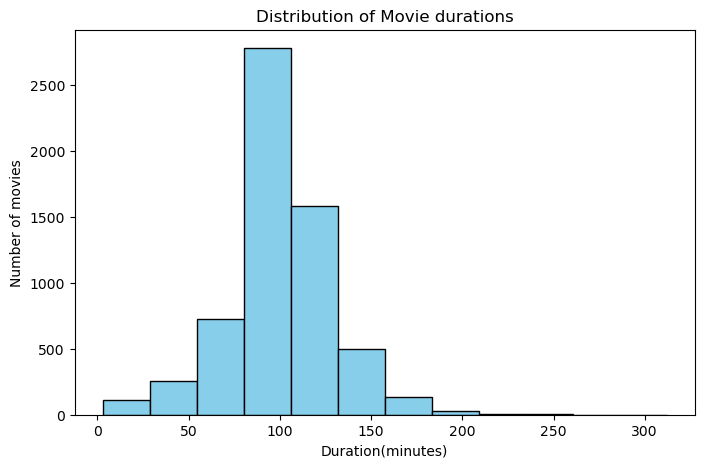

In [206]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(movies['duration_min'],bins=12,color='skyblue',edgecolor='black')
plt.title('Distribution of Movie durations')
plt.xlabel('Duration(minutes)')
plt.ylabel('Number of movies')
plt.show()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


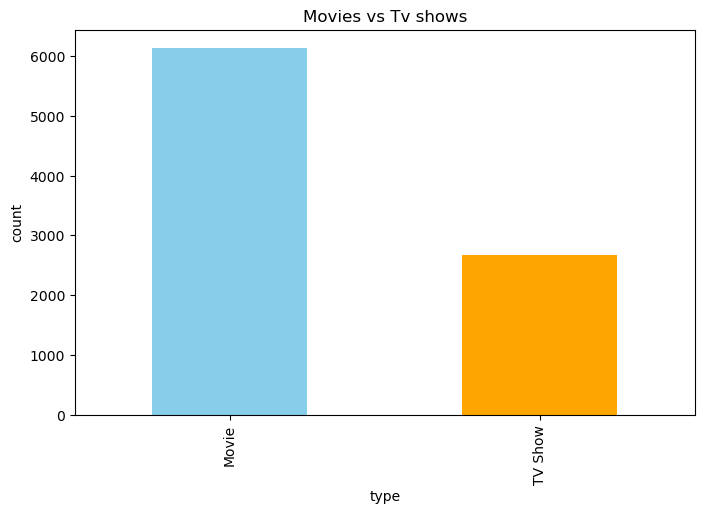

In [50]:
from matplotlib import pyplot as plt
total_count=df['type'].value_counts()
print(total_count)
total_count.plot(kind='bar',color=['skyblue','orange'],figsize=(8,5))
plt.title('Movies vs Tv shows')
plt.ylabel('count')
plt.show()

In [60]:
df['country'].fillna('unknown',inplace=True)
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [62]:
df['country']=df['country'].astype(str)
df['country_list']=df['country'].apply(lambda x : [c.strip() for c in x.split(',')])
df['country_list']


0       [United States]
1        [South Africa]
2             [unknown]
3             [unknown]
4               [India]
             ...       
8802    [United States]
8803          [unknown]
8804    [United States]
8805    [United States]
8806            [India]
Name: country_list, Length: 8807, dtype: object

country_list
[United States]     2818
[India]              972
[unknown]            831
[United Kingdom]     419
[Japan]              245
[South Korea]        199
[Canada]             181
[Spain]              145
[France]             124
[Mexico]             110
[Egypt]              106
Name: count, dtype: int64


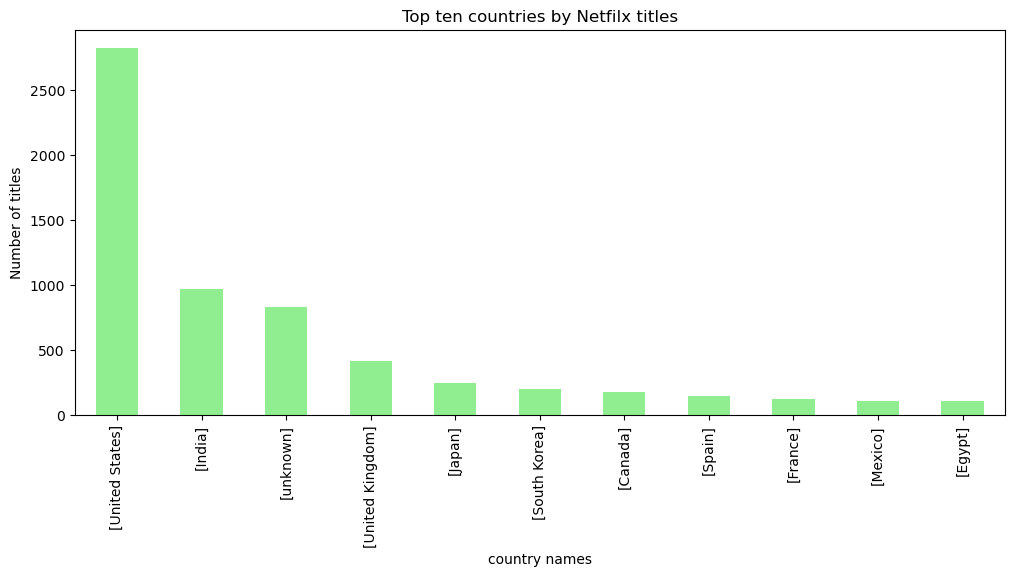

In [64]:
from matplotlib import pyplot as plt
country_count=df['country_list'].value_counts().head(11)
print(country_count)
country_count.plot(kind='bar',color='lightgreen',figsize=(12,5))
plt.title('Top ten countries by Netfilx titles')
plt.xlabel('country names')
plt.ylabel('Number of titles')
plt.show()


In [66]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'country_list'],
      dtype='object')

In [68]:
title_count=df['release_year'].value_counts().head(5)
print(title_count)
count=title_count.max()
year=title_count.idxmax()
print('The year with most releases is', {year} ,'with', {count} ,'titles')

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64
The year with most releases is {2018} with {1147} titles


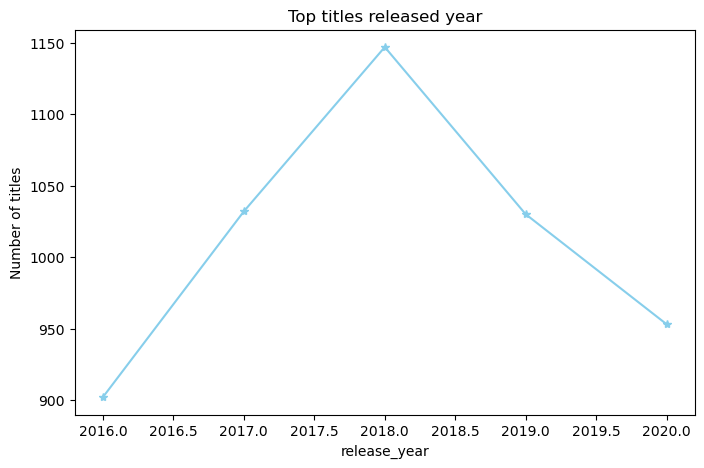

In [70]:
from matplotlib import pyplot as plt
title_count.sort_index().plot(kind='line',color='skyblue',figsize=(8,5),marker='*')
plt.title('Top titles released year')
plt.ylabel('Number of titles')
plt.show()

In [72]:
df['director'].isnull().sum()

2634

In [104]:
df['director'].fillna('unknown',inplace=True)
df['director']


0       Kirsten Johnson
1               unknown
2       Julien Leclercq
3               unknown
4               unknown
             ...       
8802      David Fincher
8803            unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object

In [112]:
director_count=df[df['director']!='unknown']['director'].value_counts().head(10)
print(director_count)
count=director_count.max()
director_name=director_count.idxmax()
print('More number of titles are given by',{director_name},'and their count', {count})

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64
More number of titles are given by {'Rajiv Chilaka'} and their count {19}


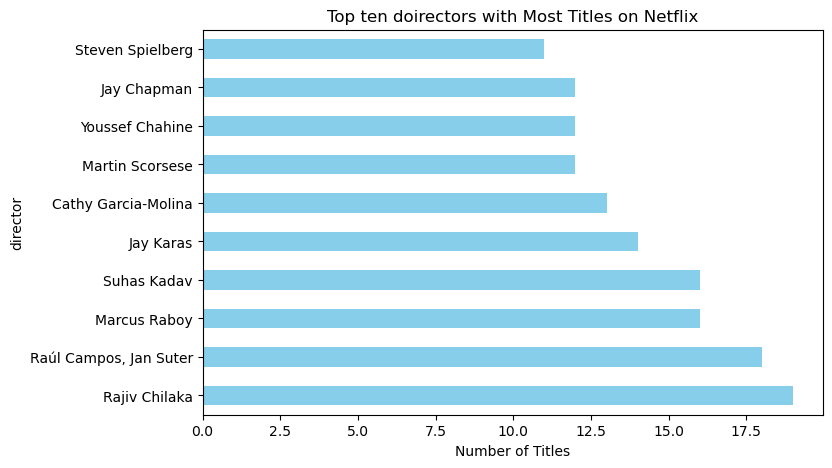

In [118]:
from matplotlib import pyplot as plt
director_count.plot(kind='barh',color='skyblue',figsize=(8,5))
plt.title('Top ten doirectors with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.show()

In [120]:
df['rating'].isnull().sum()

4

In [128]:
df['rating'].fillna('unknown',inplace=True)
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[United States]
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",[South Africa]
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,[unknown]


In [132]:
rating_count=df['rating'].value_counts()
rating_count

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

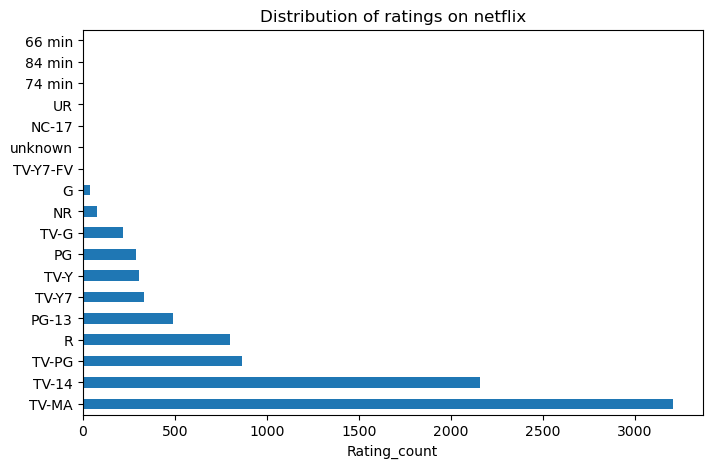

In [150]:
from matplotlib import pyplot as plt
rating_count.plot(kind='barh',figsize=(8,5))
plt.title('Distribution of ratings on netflix')
plt.xlabel('Rating_count')
plt.ylabel('')
plt.show()
